This report presents an Exploratory Data Analysis (EDA) of the EEG Eye State dataset, composed of 14 EEG channel measurements and a binary target indicating eye state (0 = open, 1 = closed). The goal is to assess data structure and quality, understand target distribution, and inspect feature behavior (distributions, outliers, correlations) to inform subsequent preprocessing and modeling decisions.

Dataset download from ucimlrepo

In [6]:
# Install required package for accessing UCI datasets
!pip install ucimlrepo

# Import necessary libraries
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import norm, skew, kurtosis, shapiro
# Fetch the EEG Eye State dataset (ID: 264)
eeg_eye_state = fetch_ucirepo(id=264)



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


 Extract features and targets as pandas DataFrames


In [7]:
X = eeg_eye_state.data.features  # EEG features (14 columns)
y = eeg_eye_state.data.targets   # Eye state labels (0=open, 1=closed)

Preview the data

In [8]:
# Preview the data
print("\nFirst 5 rows of features (EEG data):")
print(X.head())
print("\nFirst 5 rows of target (eye state):")
print(y.head())


First 5 rows of features (EEG data):
       AF3       F7       F3      FC5       T7       P7       O1       O2  \
0  4329.23  4009.23  4289.23  4148.21  4350.26  4586.15  4096.92  4641.03   
1  4324.62  4004.62  4293.85  4148.72  4342.05  4586.67  4097.44  4638.97   
2  4327.69  4006.67  4295.38  4156.41  4336.92  4583.59  4096.92  4630.26   
3  4328.72  4011.79  4296.41  4155.90  4343.59  4582.56  4097.44  4630.77   
4  4326.15  4011.79  4292.31  4151.28  4347.69  4586.67  4095.90  4627.69   

        P8       T8      FC6       F4       F8      AF4  
0  4222.05  4238.46  4211.28  4280.51  4635.90  4393.85  
1  4210.77  4226.67  4207.69  4279.49  4632.82  4384.10  
2  4207.69  4222.05  4206.67  4282.05  4628.72  4389.23  
3  4217.44  4235.38  4210.77  4287.69  4632.31  4396.41  
4  4210.77  4244.10  4212.82  4288.21  4632.82  4398.46  

First 5 rows of target (eye state):
   eyeDetection
0             0
1             0
2             0
3             0
4             0


### 🔎 Data Preview & Signal Structure Analysis
Examining the first few rows (`head`) reveals three critical technical insights that will guide our preprocessing strategy:

1.  **DC Offset (Baseline Bias):**
    The raw EEG values do not oscillate around zero (as expected in pure electrical signals) but are shifted around a baseline of **~4000-4600**.
    *   *Implication:* This indicates a hardware DC offset. For distance-based algorithms (like kNN or SVM) and Neural Networks, it is mandatory to **center** or **standardize** the data (e.g., `StandardScaler`), otherwise, the model will learn the bias rather than the signal variations.

2.  **Short-Term Stability (Autocorrelation):**
    Values change minimally between consecutive rows (e.g., AF3 moves from 4329 to 4324).
    *   *Implication:* This confirms the high sampling rate (~128Hz). Adjacent samples are strongly **autocorrelated**, meaning we cannot treat them as independent and identically distributed (i.i.d.) observations. This reinforces the need for **time-series validation** (avoiding random shuffle split) to prevent data leakage.

3.  **Target Variable:**
    The `eyeDetection` column is a binary integer (0/1), confirming this is a standard **binary classification task**.



What do the feature columns represent?
Each feature (column) corresponds to the electrical activity of the brain measured at a specific EEG electrode, following the international 10–20 system.

### EEG Feature Columns

| Column | Brain region | What it represents |
| :--- | :--- | :--- |
| AF3 | Anterior frontal (left) | Attention, focus |
| AF4 | Anterior frontal (right) | Attention, decision making |
| F3 | Frontal (left) | Thinking, memory |
| F4 | Frontal (right) | Cognitive control |
| F7 | Frontal lateral (left) | Emotion processing |
| F8 | Frontal lateral (right) | Emotion processing |
| FC5 | Fronto-central (left) | Motor planning |
| FC6 | Fronto-central (right) | Motor planning |
| T7 | Temporal (left) | Auditory processing |
| T8 | Temporal (right) | Auditory processing |
| P7 | Parietal (left) | Spatial awareness |
| P8 | Parietal (right) | Spatial awareness |
| O1 | Occipital (left) | Visual processing |
| O2 | Occipital (right) | Visual processing |

CREATE A COMPLETE DATAFRAME

In [9]:
# Create a complete DataFrame
df = eeg_eye_state.data.features.copy()
df['eye_state'] = eeg_eye_state.data.targets.values
print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"Dataset Shape: {df.shape}")
print(f"Number of EEG Channels: {len(df.columns) - 1}")
print(f"Total Observations: {len(df)}")
print(f"Chronological Recording Duration: 117 seconds")
print(f"Approximate Sampling Rate: {len(df)/117:.1f} Hz")

DATASET OVERVIEW
Dataset Shape: (14980, 15)
Number of EEG Channels: 14
Total Observations: 14980
Chronological Recording Duration: 117 seconds
Approximate Sampling Rate: 128.0 Hz


BASIC DATA PROFILING


In [10]:
print("\n" + "=" * 80)
print("1. BASIC DATA PROFILING")
print("=" * 80)

# Check data types and missing values
print("\nData Types and Missing Values:")
info_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
print(info_df)


1. BASIC DATA PROFILING

Data Types and Missing Values:
          Data Type  Missing Values  Missing %
AF3         float64               0        0.0
F7          float64               0        0.0
F3          float64               0        0.0
FC5         float64               0        0.0
T7          float64               0        0.0
P7          float64               0        0.0
O1          float64               0        0.0
O2          float64               0        0.0
P8          float64               0        0.0
T8          float64               0        0.0
FC6         float64               0        0.0
F4          float64               0        0.0
F8          float64               0        0.0
AF4         float64               0        0.0
eye_state     int64               0        0.0


Basic statistics

In [11]:
print("\nDescriptive Statistics:")
print(df.describe().T)


Descriptive Statistics:
             count         mean          std        min      25%      50%  \
AF3        14980.0  4321.917777  2492.072174  1030.7700  4280.51  4294.36   
F7         14980.0  4009.767694    45.941672  2830.7700  3990.77  4005.64   
F3         14980.0  4264.022433    44.428052  1040.0000  4250.26  4262.56   
FC5        14980.0  4164.946326  5216.404632  2453.3300  4108.21  4120.51   
T7         14980.0  4341.741075    34.738821  2089.7400  4331.79  4338.97   
P7         14980.0  4644.022379  2924.789537  2768.2100  4611.79  4617.95   
O1         14980.0  4110.400160  4600.926543  2086.1500  4057.95  4070.26   
O2         14980.0  4616.056904    29.292603  4567.1800  4604.62  4613.33   
P8         14980.0  4218.826610  2136.408523  1357.9500  4190.77  4199.49   
T8         14980.0  4231.316200    38.050903  1816.4100  4220.51  4229.23   
FC6        14980.0  4202.456900    37.785981  3273.3300  4190.26  4200.51   
F4         14980.0  4279.232774    41.544312  2257.

### ✅ Data Integrity Check: No Missing Values

**Key Finding:** The dataset shows **0% missing values** across all 15 features (14 EEG channels + target).

**Why this matters:**
*   **Positive sign:** This suggests a **controlled laboratory recording** with continuous electrode contact throughout the 117-second session. In real-world EEG data, missing values are common due to:
    *   Electrode detachment
    *   Artifacts leading to signal rejection
    *   Pre-processing filters removing corrupted segments
    
*   **Implication for preprocessing:**
    *   We can skip imputation strategies (no need for mean/median filling or advanced techniques like KNN imputation).
    *   However, we must remain vigilant about **extreme outliers** (which we already noticed in the `describe()` output). Zero missing values doesn't guarantee zero noise.

**Data types:** All features are correctly stored as `float64`, which is suitable for numerical modeling. The target (`eyeDetection`) could be converted to `int8` or `category` to save memory, but for a dataset of ~15K rows, this optimization is negligible.

---
**Next step:** Move to descriptive statistics to quantify the distribution and detect anomalies.


TARGET VARIABLE ANALYSIS

In [30]:
print("\n" + "=" * 80)
print("TARGET VARIABLE ANALYSIS")
print("=" * 80)


TARGET VARIABLE ANALYSIS


Eye state distribution

In [31]:
eye_state_counts = df['eye_state'].value_counts()
eye_state_percent = df['eye_state'].value_counts(normalize=True) * 100

print(f"\nEye State Distribution:")
print(f"Eye Open (0): {eye_state_counts[0]} samples ({eye_state_percent[0]:.2f}%)")
print(f"Eye Closed (1): {eye_state_counts[1]} samples ({eye_state_percent[1]:.2f}%)")


Eye State Distribution:
Eye Open (0): 8257 samples (55.12%)
Eye Closed (1): 6723 samples (44.88%)


Check for class imbalance

In [32]:
imbalance_ratio = eye_state_counts[0] / eye_state_counts[1]
print(f"\nClass Imbalance Ratio (Open/Closed): {imbalance_ratio:.3f}")


Class Imbalance Ratio (Open/Closed): 1.228


### Comprehensive distribution overview (14 EEG channels + target)


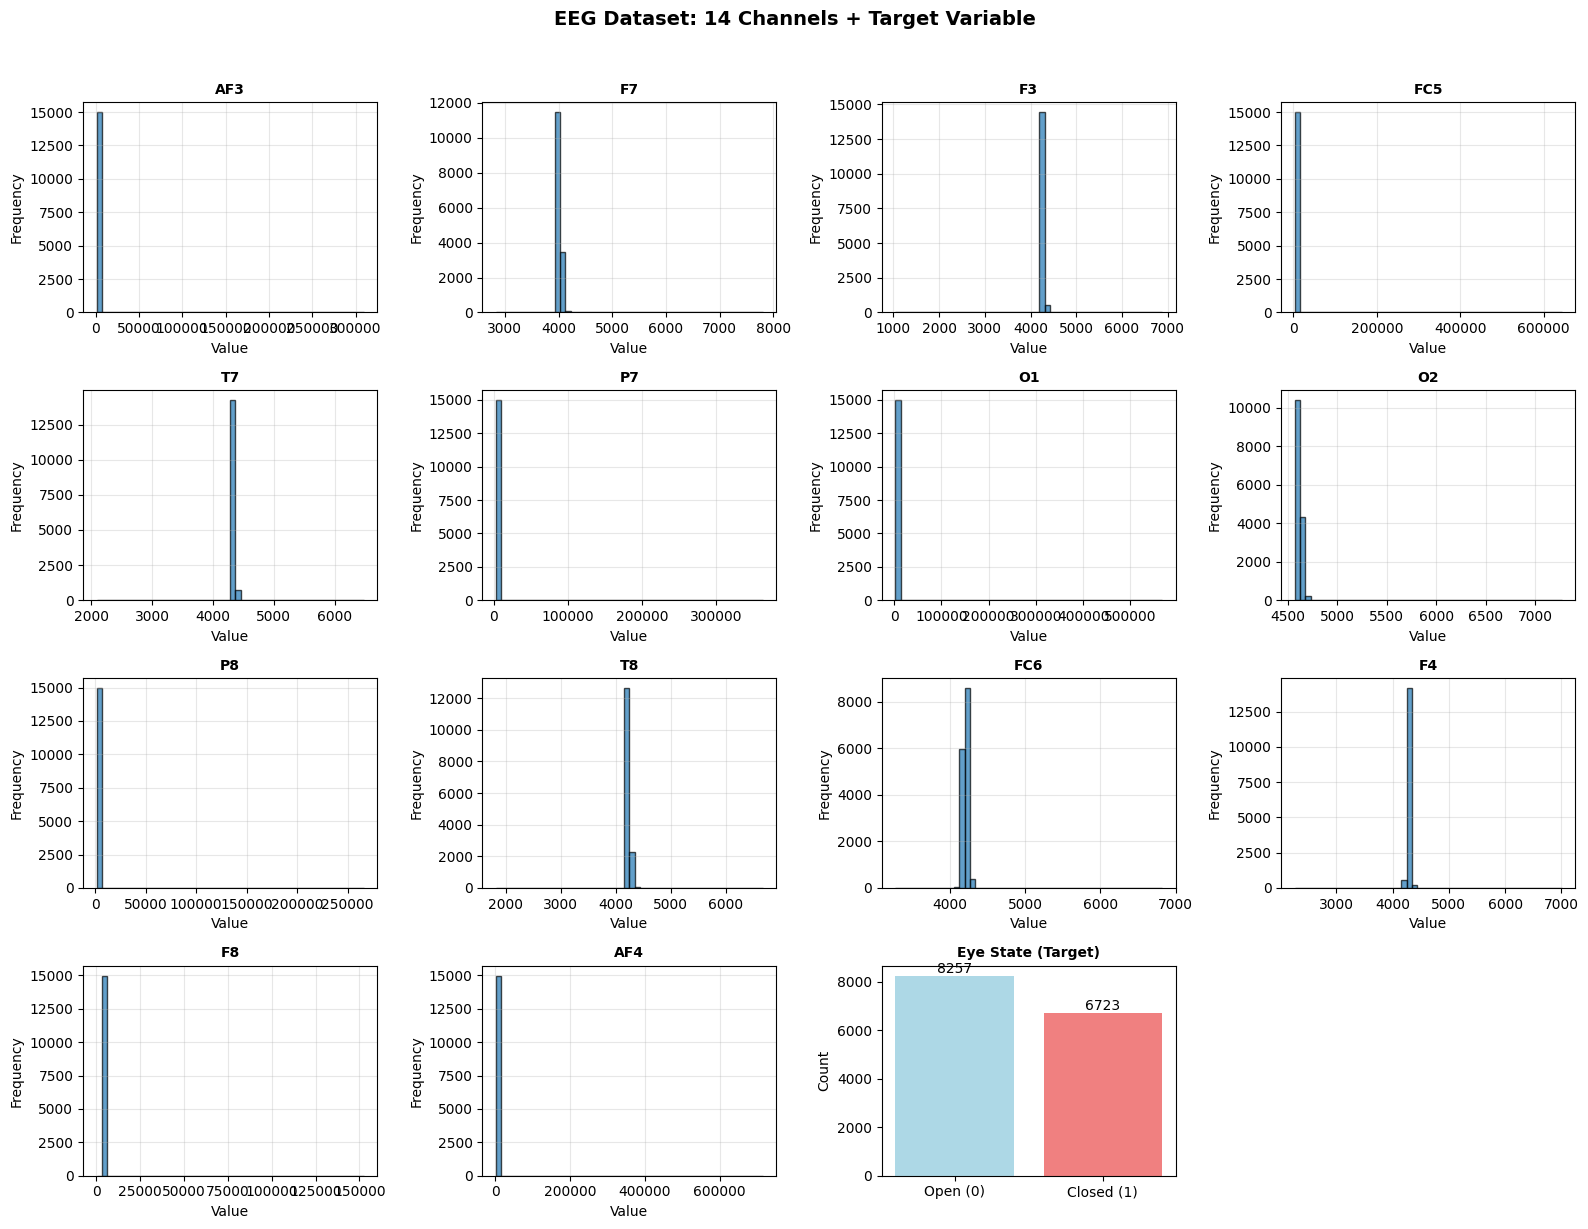

In [16]:
# Get EEG channel names (all columns except the target)
eeg_channels = [col for col in df.columns if col != 'eye_state']

# Create 4x4 grid of subplots
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.ravel()  # Flatten to 1D array for easy indexing

# Plot EEG channels (first 14 subplots)
for i, channel in enumerate(eeg_channels):
    ax = axes[i]
    ax.hist(df[channel], bins=50, alpha=0.7, edgecolor='black')
    ax.set_title(channel, fontsize=10, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)

# Plot target variable (15th subplot)
ax_target = axes[14]
eye_state_counts = df['eye_state'].value_counts().sort_index()
bars = ax_target.bar(['Open (0)', 'Closed (1)'], eye_state_counts.values, 
                     color=['lightblue', 'lightcoral'])
ax_target.set_title('Eye State (Target)', fontsize=10, fontweight='bold')
ax_target.set_ylabel('Count')

# Add count labels on bars
for bar, count in zip(bars, eye_state_counts.values):
    height = bar.get_height()
    ax_target.text(bar.get_x() + bar.get_width()/2., height,
                   f'{count}', ha='center', va='bottom')

# Hide the 16th subplot (empty)
axes[15].set_visible(False)

# Adjust layout and show
plt.suptitle('EEG Dataset: 14 Channels + Target Variable', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


The histograms show that most EEG channels are concentrated around a high baseline (~4k–4.6k), indicating a strong DC offset rather than zero-centered oscillations.  
Several channels exhibit extreme right-tail values (rare, very large spikes), which stretch the x-axis and visually compress the bulk of the distribution into a narrow band.  
This suggests the need for robust preprocessing (e.g., centering/standardization and outlier-aware scaling) before training distance-based or gradient-based models. 
The target “Eye State” distribution is only mildly imbalanced (Open > Closed), so standard stratified splits and metrics like F1/ROC-AUC are appropriate.

### EEG channels distribution (log scale)


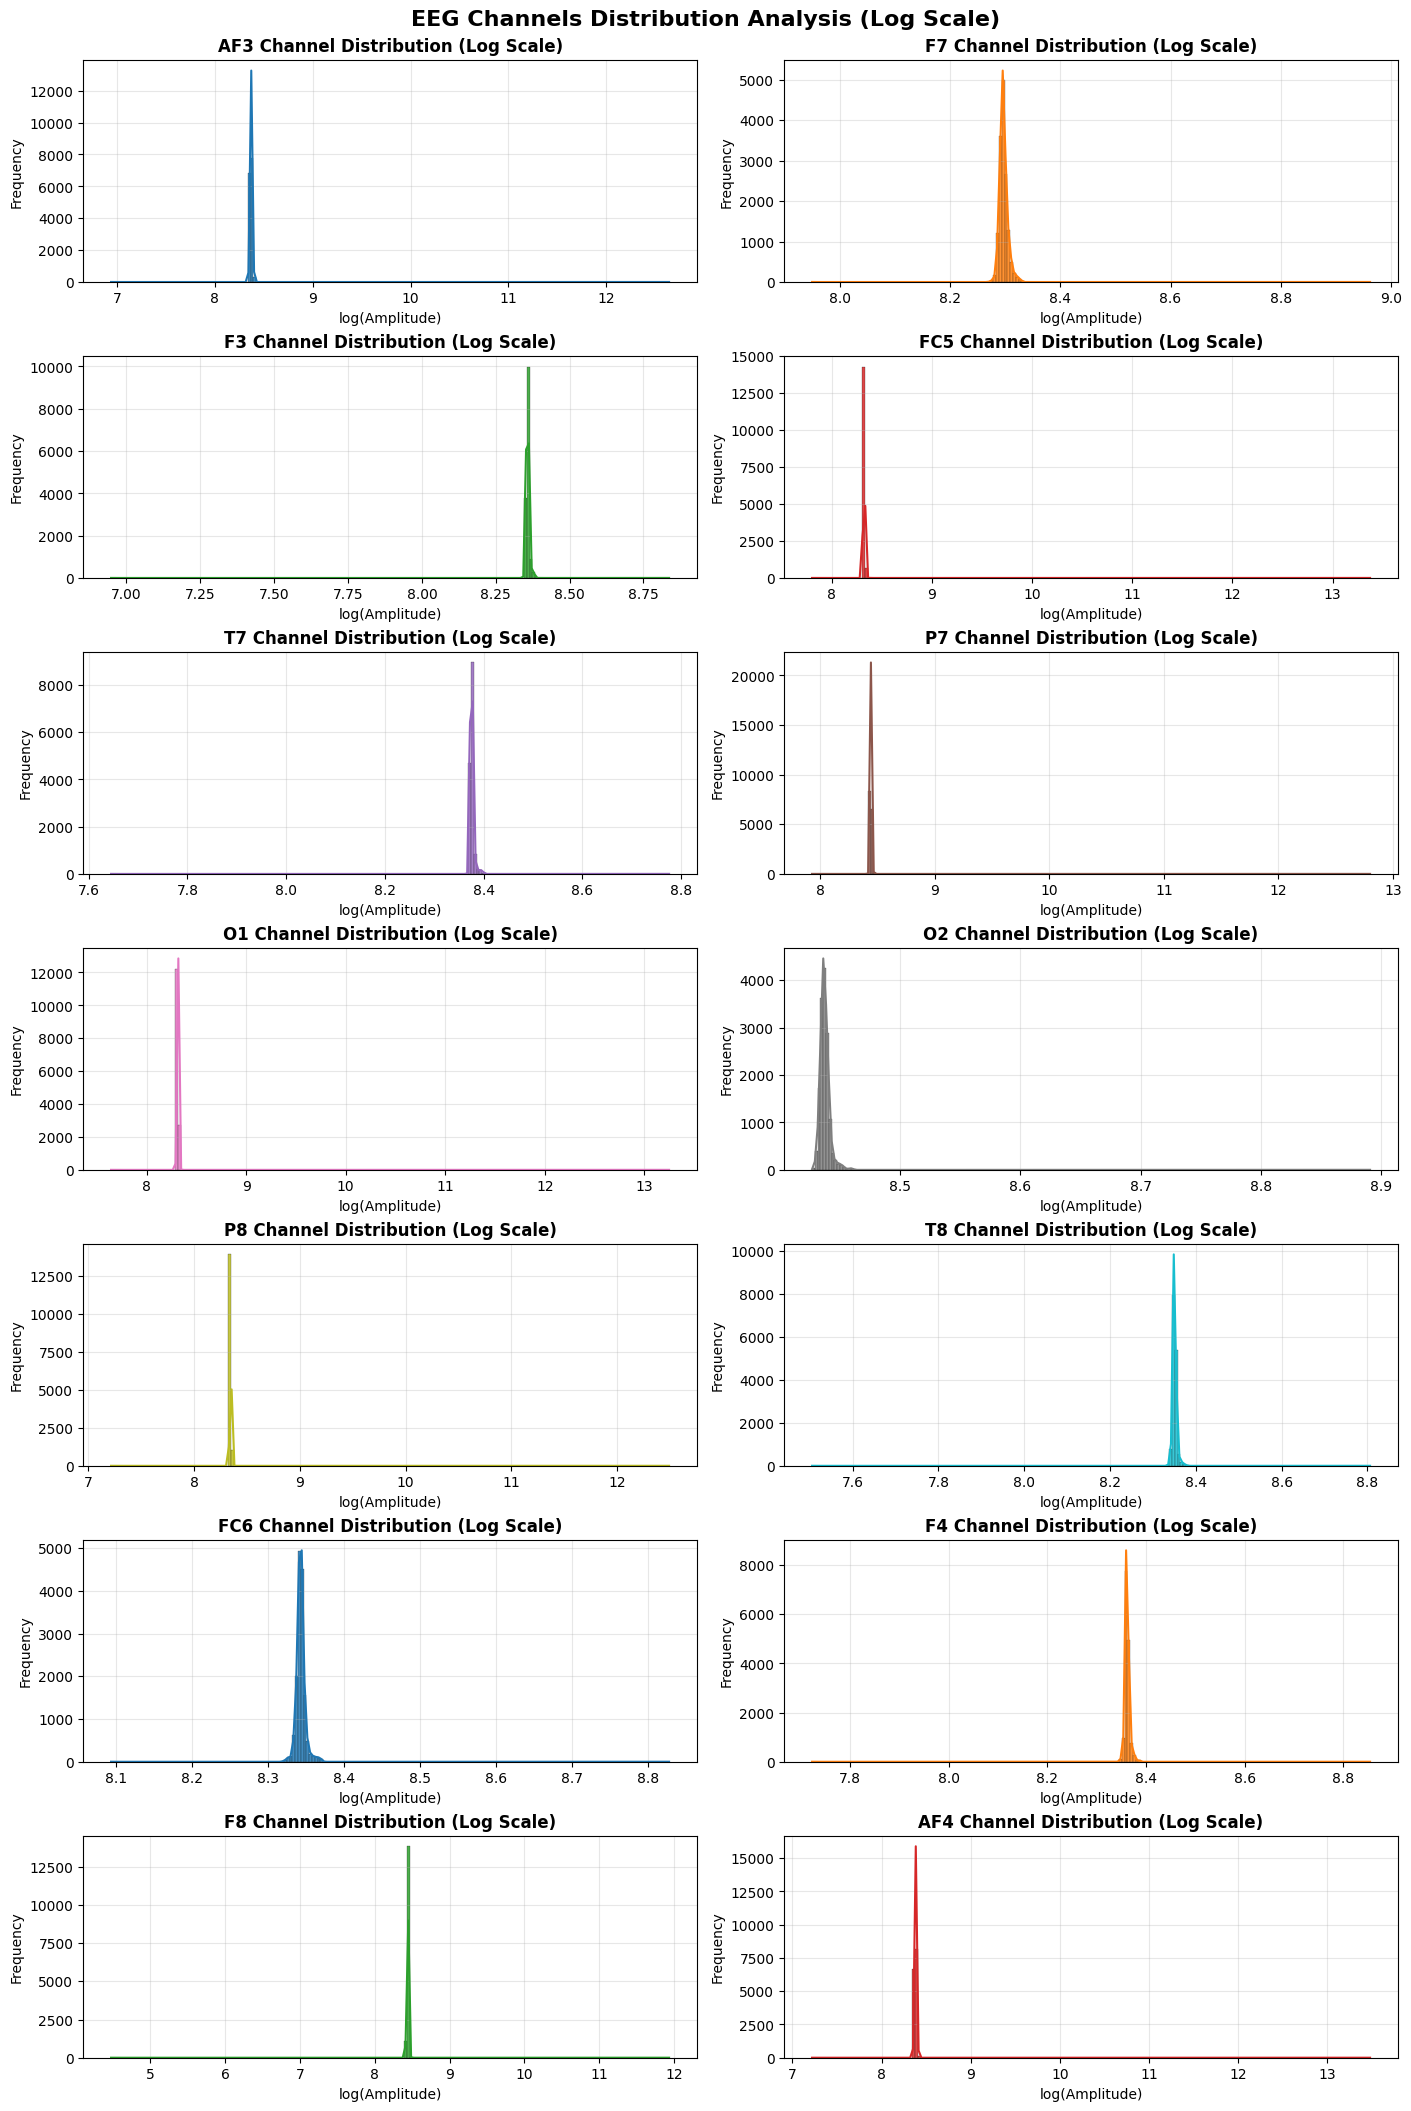

In [22]:

# Create distribution plots with log scale
n_cols = 2
n_rows = (len(eeg_channels) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(14, n_rows * 3),
    constrained_layout=True
)
axes = axes.flatten()
colors = sns.color_palette("tab10", len(eeg_channels))

for i, channel in enumerate(eeg_channels):
    sns.histplot(
        x=np.log1p(df[channel]),
        bins=200,
        kde=True,
        color=colors[i],
        alpha=0.85,
        ax=axes[i]
    )
    
    axes[i].set_title(
        f"{channel} Channel Distribution (Log Scale)",
        fontsize=12,
        fontweight="bold"
    )
    axes[i].set_xlabel("log(Amplitude)")
    axes[i].set_ylabel("Frequency")
    axes[i].grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "EEG Channels Distribution Analysis (Log Scale)",
    fontsize=16,
    fontweight="bold"
)
plt.show()

These histograms use a log transform (`log1p`) to compress the extreme amplitudes and make the main structure of each channel readable even in the presence of rare, very large spikes. 
With the log scale, most channels show a compact peak (narrow spread) around a similar range, confirming the strong baseline/DC offset observed in the raw values.  
Outliers are still visible as long right tails, but they no longer dominate the x-axis, so the “typical” variability becomes comparable across channels. 
Overall, the plot suggests that preprocessing should include centering/standardization (and possibly robust scaling) and that artifact/outlier handling remains important despite the log transform. 

MEEAN EEG AMPLITUDE PER CHANNEL BY EYE STATE


MEAN EEG AMPLITUDE PER CHANNEL BY EYE STATE


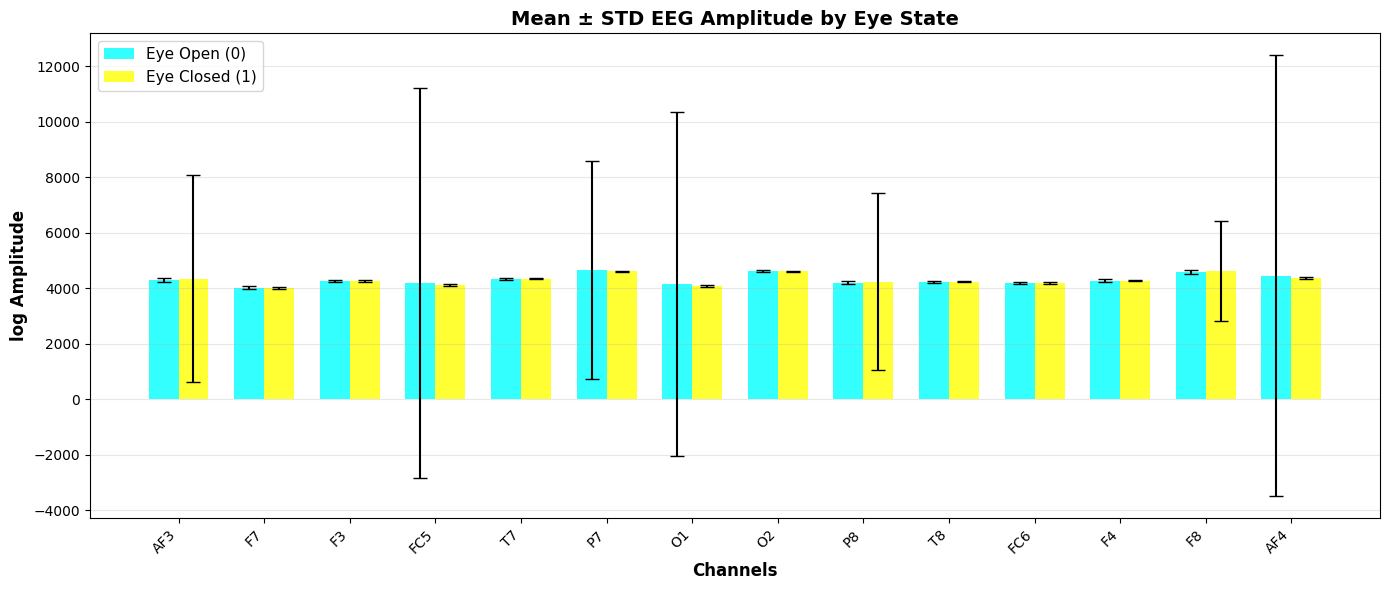


Mean Amplitude Summary by Eye State:
Channel   Open_Mean    Open_Std  Closed_Mean  Closed_Std  Difference
    AF3 4298.402552   71.727033  4350.798517 3719.031369   52.395965
     F7 4013.083756   54.006143  4005.694999   33.028602   -7.388756
     F3 4262.462922   49.172179  4265.937779   37.710772    3.474857
    FC5 4200.391388 7026.078621  4121.413696   26.527445  -78.977692
     T7 4341.752633   42.109983  4341.726881   22.610379   -0.025752
     P7 4664.726001 3939.432964  4618.594772   18.992404  -46.131229
     O1 4140.387390 6197.052117  4073.570684   34.213632  -66.816706
     O2 4615.393493   35.723325  4616.871687   18.532877    1.478194
     P8 4200.367181   48.380447  4241.497964 3188.564108   41.130783
     T8 4229.695026   47.996940  4233.307279   19.742126    3.612253
    FC6 4200.264826   35.944185  4205.149143   39.769668    4.884317
     F4 4277.434783   48.448991  4281.441017   30.889516    4.006235
     F8 4600.899882   77.430622  4632.774892 1801.617595   31.875

In [23]:
# Calculate mean EEG amplitude by eye state
print("\n" + "=" * 80)
print("MEAN EEG AMPLITUDE PER CHANNEL BY EYE STATE")
print("=" * 80)

# Compute mean and std for each channel by eye state
eeg_channels = [col for col in df.columns if col != 'eye_state']
mean_by_state = df.groupby('eye_state')[eeg_channels].agg(['mean', 'std'])

# Create visualization
fig, ax = plt.subplots(figsize=(14, 6))

# Prepare data for plotting
channels = eeg_channels
eye_open_means = [df[df['eye_state'] == 0][ch].mean() for ch in channels]
eye_open_stds = [df[df['eye_state'] == 0][ch].std() for ch in channels]
eye_closed_means = [df[df['eye_state'] == 1][ch].mean() for ch in channels]
eye_closed_stds = [df[df['eye_state'] == 1][ch].std() for ch in channels]

# Set positions for bars
x = np.arange(len(channels))
width = 0.35

# Create bars with error bars
bars1 = ax.bar(x - width/2, eye_open_means, width, label='Eye Open (0)', 
               yerr=eye_open_stds, capsize=5, alpha=0.8, color='cyan')
bars2 = ax.bar(x + width/2, eye_closed_means, width, label='Eye Closed (1)', 
               yerr=eye_closed_stds, capsize=5, alpha=0.8, color='yellow')

ax.set_xlabel('Channels', fontsize=12, fontweight='bold')
ax.set_ylabel('log Amplitude', fontsize=12, fontweight='bold')
ax.set_title('Mean ± STD EEG Amplitude by Eye State', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(channels, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print summary table
print("\nMean Amplitude Summary by Eye State:")
summary_df = pd.DataFrame({
    'Channel': channels,
    'Open_Mean': eye_open_means,
    'Open_Std': eye_open_stds,
    'Closed_Mean': eye_closed_means,
    'Closed_Std': eye_closed_stds,
    'Difference': [c - o for c, o in zip(eye_closed_means, eye_open_means)]
})
print(summary_df.to_string(index=False))

- The plot compares **Eye Open (0)** vs **Eye Closed (1)** using the per-channel mean EEG amplitude (shown in log scale). [file:7]  
- Across most channels, the **mean values are close**, suggesting that the eye state does not produce a large global DC-level shift in the raw amplitudes; differences (when present) look subtle and channel-dependent. [file:7]  
- The **error bars (STD)** are very large for some channels, which is consistent with the dataset having **strong outliers / heavy tails** (also visible in the descriptive stats where maxima are extremely high for some channels). [file:7]

#### OUTLIER ANALYIS

### Box plots (IQR outlier detection) — EEG channels



Outlier Analysis Summary:
Channel IQR_Outliers  IQR_Percent ZScore_Outliers  ZScore_Percent                      Method
    AF3         1485     9.913218               1        0.006676 Z-score (more conservative)
     F7          710     4.739653              17        0.113485 Z-score (more conservative)
     F3          825     5.507343               4        0.026702 Z-score (more conservative)
    FC5          601     4.012016               1        0.006676 Z-score (more conservative)
     T7          727     4.853138              37        0.246996 Z-score (more conservative)
     P7         1065     7.109479               1        0.006676 Z-score (more conservative)
     O1          348     2.323097               1        0.006676 Z-score (more conservative)
     O2          609     4.065421              66        0.440587 Z-score (more conservative)
     P8          584     3.898531               1        0.006676 Z-score (more conservative)
     T8          830     5.540721

C:\Users\11625216\AppData\Local\Temp\ipykernel_6100\743970682.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  outlier_summary = pd.concat([outlier_summary, pd.DataFrame([{


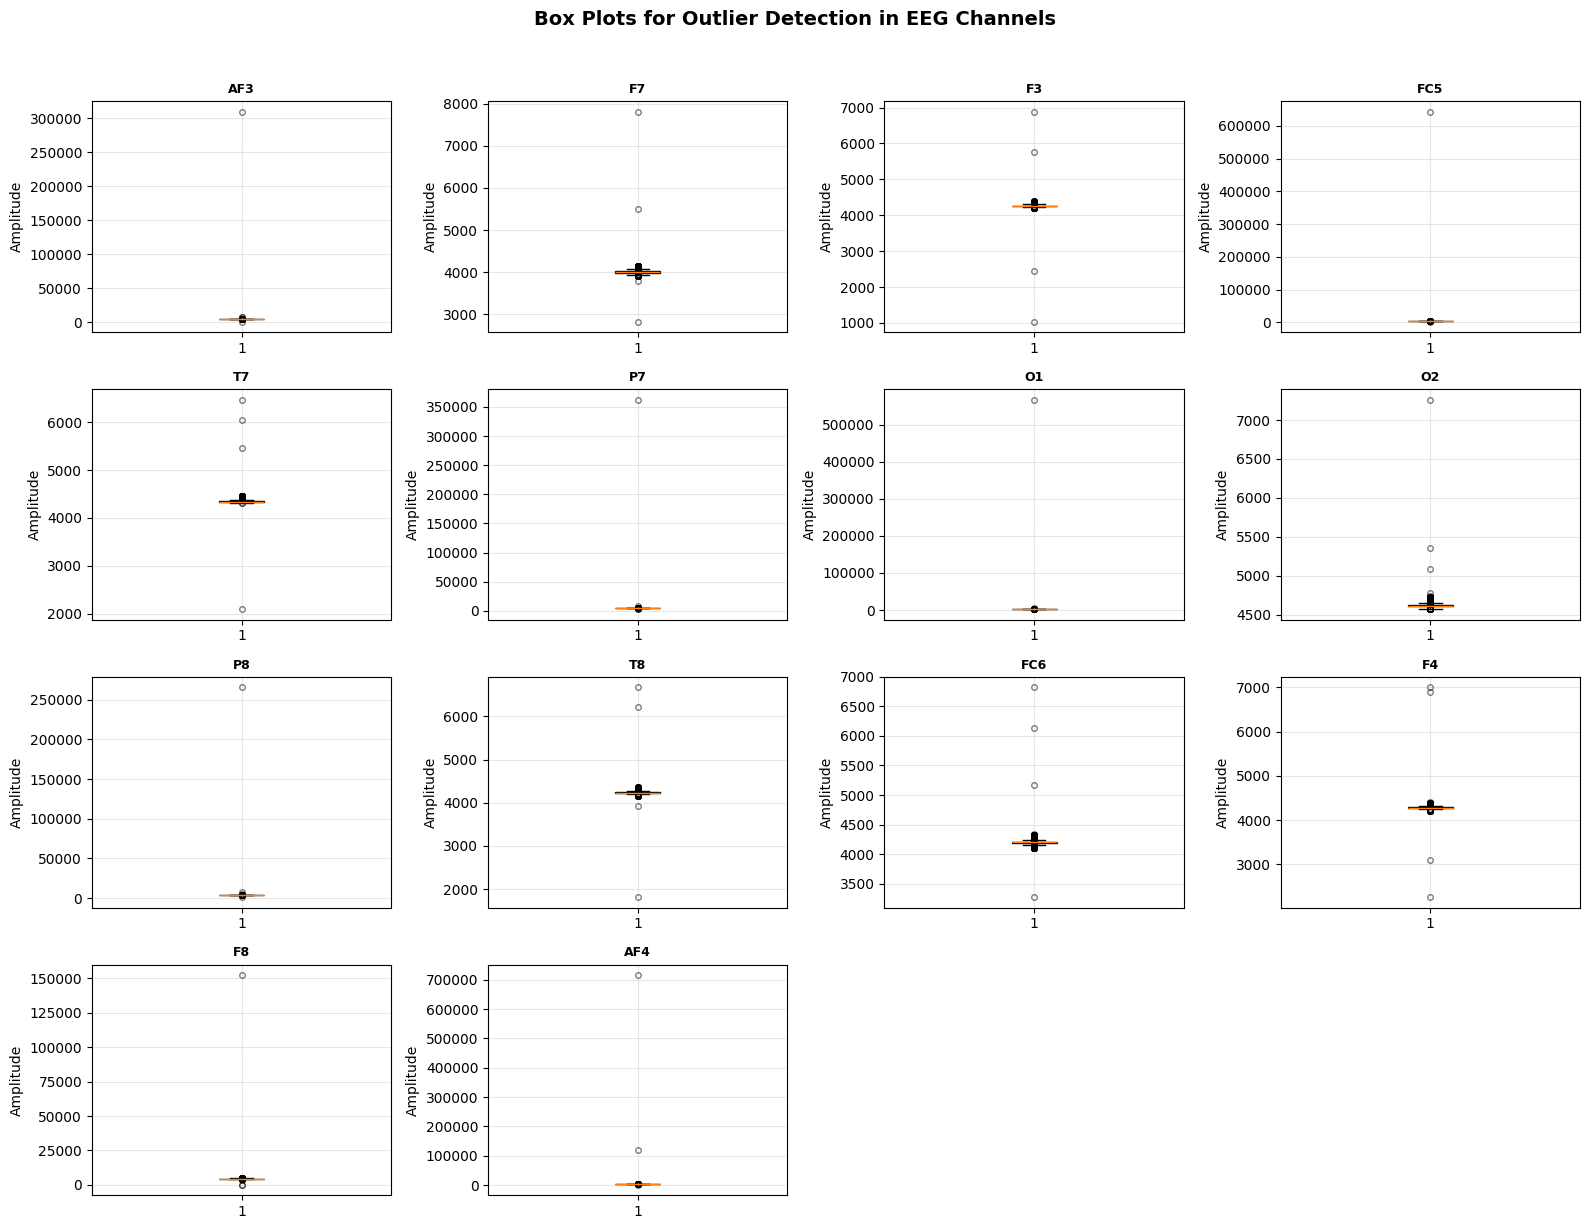

In [24]:
# Function to detect outliers using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Function to detect outliers using Z-score method
def detect_outliers_zscore(data, column, threshold=3):
    z_scores = np.abs(stats.zscore(data[column]))
    outliers = data[z_scores > threshold]
    return outliers

# Analyze outliers for each channel
outlier_summary = pd.DataFrame(columns=['Channel', 'IQR_Outliers', 'IQR_Percent', 
                                        'ZScore_Outliers', 'ZScore_Percent', 'Method'])

eeg_channels = [col for col in df.columns if col != 'eye_state']

for channel in eeg_channels:
    # IQR method
    iqr_outliers, lower_iqr, upper_iqr = detect_outliers_iqr(df, channel)
    iqr_percent = (len(iqr_outliers) / len(df)) * 100
    
    # Z-score method
    zscore_outliers = detect_outliers_zscore(df, channel, threshold=3)
    zscore_percent = (len(zscore_outliers) / len(df)) * 100
    
    # Determine which method is more conservative
    if len(iqr_outliers) > len(zscore_outliers):
        method = 'Z-score (more conservative)'
    else:
        method = 'IQR (more conservative)'
    
    outlier_summary = pd.concat([outlier_summary, pd.DataFrame([{
        'Channel': channel,
        'IQR_Outliers': len(iqr_outliers),
        'IQR_Percent': iqr_percent,
        'ZScore_Outliers': len(zscore_outliers),
        'ZScore_Percent': zscore_percent,
        'Method': method
    }])], ignore_index=True)

print("\nOutlier Analysis Summary:")
print(outlier_summary.to_string(index=False))

# Visualize outliers using box plots
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.ravel()

for i, channel in enumerate(eeg_channels):
    ax = axes[i]
    bp = ax.boxplot(df[channel], vert=True, patch_artist=True)
    
    # Color outliers differently
    bp['fliers'][0].set(marker='o', color='red', alpha=0.5, markersize=4)
    bp['boxes'][0].set(facecolor='lightblue')
    
    ax.set_title(f'{channel}', fontsize=9, fontweight='bold')
    ax.set_ylabel('Amplitude')
    ax.grid(True, alpha=0.3)

# Remove empty subplots
for i in range(len(eeg_channels), 16):
    axes[i].set_visible(False)

plt.suptitle('Box Plots for Outlier Detection in EEG Channels', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


- Each subplot shows the distribution of one EEG channel; the box represents the interquartile range (IQR), the line is the median, and the points outside the whiskers are flagged as **outliers** (Matplotlib boxplot). [file:7]  
- The boxes are concentrated around the usual baseline range (≈ 4k–4.6k), while several channels exhibit **extreme spikes** with very large maxima (e.g., AF4 max ≈ 715,897; FC5 max ≈ 642,564; O1 max ≈ 567,179; AF3 max ≈ 309,231). [file:7]  
- Because the IQR is relatively small compared to those spikes, the **IQR rule labels many samples as outliers** in some channels (e.g., AF4 ≈ 10.63%, AF3 ≈ 9.91%, F8 ≈ 9.75%, P7/FC6 ≈ 7.1%). [file:7]  
- In the notebook’s summary, the **Z-score method (threshold=3) is more conservative** than IQR for all channels (e.g., often ~0.006%–0.44% vs several % with IQR). [file:7]  
- Practical implication: the data are heavy‑tailed / artifact‑prone; downstream modeling should consider **robust scaling** or **artifact handling** (e.g., clipping/winsorization per channel, robust scalers, or removing windows containing extreme spikes) to prevent these points from dominating learning. [file:7]  


## Channel correlation analysis (EEG)

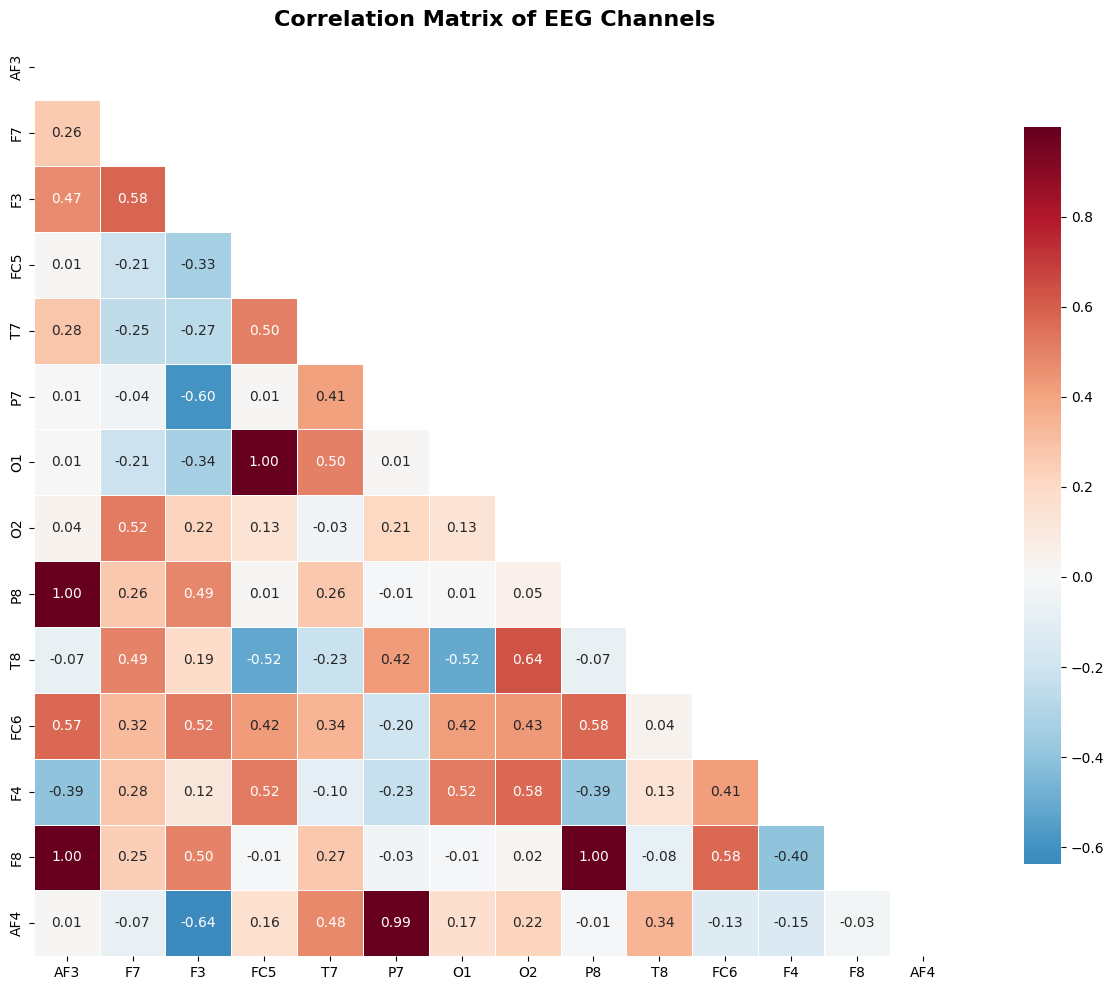


Strong Correlations (|r| > 0.7):
Channel1 Channel2  Correlation
     FC5       O1     0.999961
     AF3       P8     0.999607
      P8       F8     0.998849
     AF3       F8     0.998714
      P7      AF4     0.988310


In [29]:

# Calculate correlation matrix
corr_matrix = df[eeg_channels].corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of EEG Channels', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Find strong correlations
strong_corr_threshold = 0.7
strong_correlations = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > strong_corr_threshold:
            strong_correlations.append({
                'Channel1': corr_matrix.columns[i],
                'Channel2': corr_matrix.columns[j],
                'Correlation': corr_value
            })

strong_corr_df = pd.DataFrame(strong_correlations)
print(f"\nStrong Correlations (|r| > {strong_corr_threshold}):")
if len(strong_corr_df) > 0:
    print(strong_corr_df.sort_values('Correlation', key=lambda x: abs(x), ascending=False).to_string(index=False))
else:
    print("No strong correlations found.")


This heatmap shows the **Pearson correlation** between each pair of EEG channels, i.e., how much two channels vary together over time. [file:7]  
Red cells indicate positive correlation (signals increase/decrease together), blue cells indicate negative correlation (one tends to increase while the other decreases), and values close to ±1 mean very strong linear association. [file:7]  

### Key observations
Several channel pairs are **extremely** correlated (|r| > 0.7), with near-perfect values such as **FC5–O1 ≈ 0.99996**, **AF3–P8 ≈ 0.99961**, **P8–F8 ≈ 0.99885**, **AF3–F8 ≈ 0.99871**, and **P7–AF4 ≈ 0.98831**. [file:7]  
Correlations this close to 1.0 suggest strong redundancy (shared variance), which can come from common reference / global trends (e.g., DC offset) and may also indicate that some channels carry almost duplicate information. [file:7]  

### Why it matters for modeling
Highly correlated features can introduce multicollinearity (especially in linear models) and may reduce the benefit of keeping all channels as separate inputs. [file:7]  
If needed, we can reduce redundancy via feature selection (drop one channel from near-duplicate pairs) or dimensionality reduction (e.g., PCA) before classification. [file:7]  

### Suggested sanity check
Given the dataset’s known baseline offset and the presence of outliers, it is useful to recompute the correlation matrix **after standardization and/or robust outlier handling** to verify that these near-1.0 correlations are not driven by artifacts. [file:7]


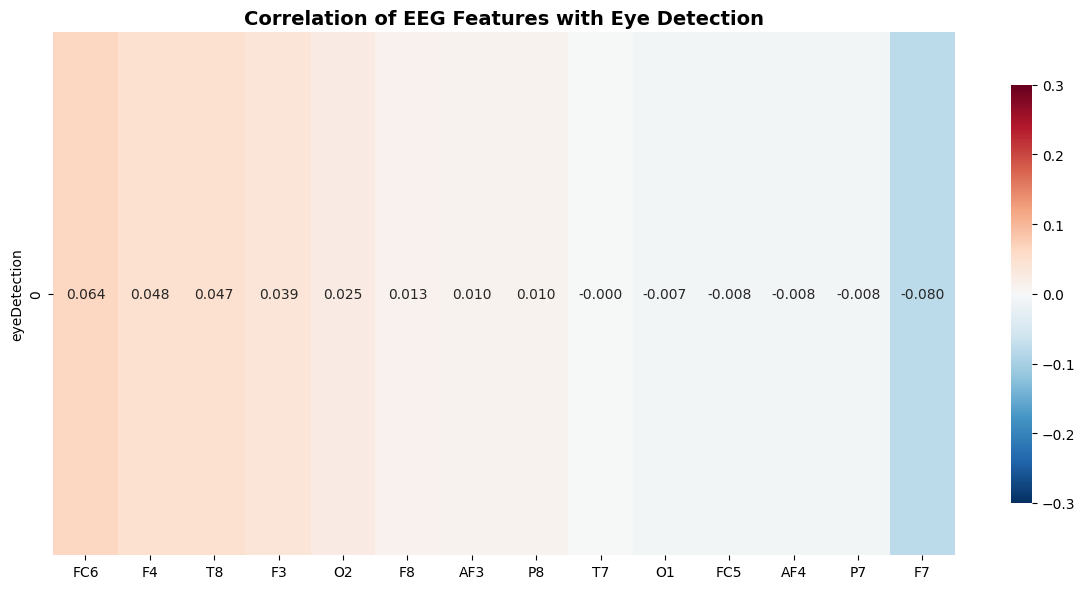


Correlation with Eye Detection:
FC6    0.064294
F4     0.047965
T8     0.047218
F3     0.038902
O2     0.025100
F8     0.013120
AF3    0.010458
P8     0.009576
T7    -0.000369
O1    -0.007223
FC5   -0.007531
AF4   -0.007550
P7    -0.007845
F7    -0.079994
dtype: float64


In [26]:
# Calculate correlation of EEG features with eye detection
corr_with_target = df[eeg_channels].corrwith(df['eye_state']).sort_values(ascending=False)

# Create heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(corr_with_target.values.reshape(1, -1), 
            annot=True, 
            fmt='.3f', 
            cmap='RdBu_r',
            center=0,
            xticklabels=corr_with_target.index,
            cbar_kws={"shrink": 0.8},
            vmin=-0.3,
            vmax=0.3)
plt.title('Correlation of EEG Features with Eye Detection', fontsize=14, fontweight='bold')
plt.ylabel('eyeDetection')
plt.tight_layout()
plt.show()

print("\nCorrelation with Eye Detection:")
print(corr_with_target)

### Correlation with eye detection (Pearson)

- The correlations between each EEG channel and the binary *eyeDetection* label are overall very small (|r| < 0.1), suggesting that no single raw channel amplitude linearly separates eye-open vs eye-closed by itself. [file:12]
- The strongest (still weak) positive association is on **FC6** (r ≈ +0.064), followed by **F4** and **T8** (≈ +0.048 / +0.047), indicating slightly higher values when the label increases. [file:12]
- The strongest negative association is **F7** (r ≈ −0.080), meaning this channel tends to decrease slightly as the label increases. [file:12]
- Most other channels are near zero (e.g., T7 ≈ 0, O1/FC5/AF4/P7 around −0.007/−0.008), implying minimal linear dependency with the target. [file:12]